# CVE to CWE Mapping

## Pre reqs:
CVE data is pulled from the Hugging Face dataset `regularpooria/NVD_CVE_699_Dataset`.
You still need to have ran scrape_cwe.ipynb so that `scrapers/scraped_data/CWE_SOFTWARE.json` exists.

### Requirements

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install sentence-transformers pandas tqdm matplotlib huggingface_hub

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.3/196.3 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.2 MB/s eta 0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 5/7 [torch]^C]
ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 5/7 [torch]
Note: you may need

In [1]:
import ast
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

## Loading scraped data

In [2]:
# !git clone https://github.com/regularpooria/CWE_CVE_Mapping # Kaggle
# BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
BASE_DIR = "../" # Local

### Loading CWE

In [3]:
!wget https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
with open(f"CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

--2026-10-05 20:55:59--  https://raw.githubusercontent.com/regularpooria/CWE_CVE_Mapping/refs/heads/main/scrapers/scraped_data/CWE_SOFTWARE.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330024 (322K) [text/plain]
Saving to: ‘CWE_SOFTWARE.json’

CWE_SOFTWARE.json   100%[===================>] 322.29K  --.-KB/s    in 0.02s   

2026-10-05 20:55:59 (13.8 MB/s) - ‘CWE_SOFTWARE.json’ saved [330024/330024]



### Loading CVE

Loaded from the Hugging Face dataset `regularpooria/NVD_CVE_699_Dataset` (`NVD_CVE_Dataset.csv`), which already contains `true_children` and `true_categories`.

In [4]:
child_to_cats = {}
for cat_id, category in CWE.items():
    for child_id in category["children"].keys():
        child_to_cats.setdefault(child_id, []).append(cat_id)

# CVE data comes from the published Hugging Face dataset.
HF_CVE_REPO_ID = "regularpooria/NVD_CVE_699_Dataset"
CVE = pd.read_csv(f"hf://datasets/{HF_CVE_REPO_ID}/NVD_CVE_Dataset.csv")

# true_children / true_categories are published as stringified lists -> parse them.
CVE["true_children"] = CVE["true_children"].apply(ast.literal_eval)
CVE["true_categories"] = CVE["true_categories"].apply(ast.literal_eval)

if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")
if (CVE["true_children"].str.len() == 0).any():
    raise ValueError("Some CVEs have a cwe_699_matches value that isn't a known CWE-699 child")

print(f"Loaded {len(CVE):,} CVE rows from {HF_CVE_REPO_ID}")

Loaded 88,146 CVE rows from regularpooria/NVD_CVE_699_Dataset


## Ground truth & helpers
`true_children` and `true_categories` are taken directly from the Hugging Face dataset (parsed above).
`parse_ids` extracts numeric CWE ids and is used to read the model labels below.

In [5]:
def parse_ids(value):
    return re.findall(r"\d+", str(value))

## Embedding

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForSequenceClassification.from_pretrained("mulliken/cwe-predictor").to(device)
tokenizer = AutoTokenizer.from_pretrained("mulliken/cwe-predictor")
model.eval()

# Model label -> numeric CWE id string ("CWE-79" -> "79")
label_ids = []
for i in range(model.config.num_labels):
    found = parse_ids(model.config.id2label[i])
    label_ids.append(found[-1] if found else None)
print("Example labels:", [model.config.id2label[i] for i in range(3)], "->", label_ids[:3])

# Optional: ignore classes that aren't CWE-699 children, so the model only chooses
# among the same candidates the hierarchical approach can return.
RESTRICT_TO_699 = False
allowed = torch.tensor(
    [(lid in child_to_cats) if RESTRICT_TO_699 else True for lid in label_ids], device=device
)

Invalid model-index. Not loading eval results into CardData.


config.json:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Example labels: ['CWE-1', 'CWE-1021', 'CWE-113'] -> ['1', '1021', '113']


In [7]:
@torch.no_grad()
def predict_topk(texts, k=10, batch_size=32, max_length=512):
    """Top-k predicted child ids per text (best first). Batched + length-sorted for speed."""
    order = np.argsort([len(t) for t in texts])
    results = [None] * len(texts)
    k = min(k, int(allowed.sum().item()))

    for start in tqdm(range(0, len(texts), batch_size)):
        idx = order[start:start + batch_size]
        enc = tokenizer(
            [texts[i] for i in idx],
            return_tensors="pt", truncation=True, max_length=max_length, padding=True,
        ).to(device)
        logits = model(**enc).logits.float()
        logits[:, ~allowed] = float("-inf")
        top = logits.topk(k, dim=-1).indices.cpu().tolist()
        for i, row in zip(idx, top):
            results[i] = [label_ids[j] for j in row]
    return results

In [8]:
CVE["top_children_flat"] = predict_topk(CVE["description"].tolist(), k=10)

# Categories implied by the ranked children (first occurrence order, de-duplicated)
def categories_from_children(children):
    seen, out = set(), []
    for c in children:
        for cat in child_to_cats.get(c, []):
            if cat not in seen:
                seen.add(cat)
                out.append(cat)
    return out

100%|██████████| 2755/2755 [06:12<00:00,  7.39it/s]


In [9]:
CVE["top_categories_flat"] = CVE["top_children_flat"].apply(categories_from_children)
CVE.head(5)


,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,true_children,true_categories,top_children_flat,top_categories_flat
0,CVE-2023-0028,2023-01-01T01:15:12.627,2026-06-17T05:24:37.547,2023,Cross-site Scripting (XSS) - Stored in GitHub ...,CWE-79,CWE-79,1,1,[79],[137],"[79, 352, 20, 94, 74, 284, 264, 787, 200, 269]","[137, 1218]"
1,CVE-2023-22451,2023-01-02T16:15:11.063,2026-06-17T05:35:28.713,2023,Kiwi TCMS is an open source test management sy...,CWE-521,CWE-521,1,1,[521],[255],"[287, 798, 326, 327, 522, 255, 347, 306, 312, ...","[255, 320, 310, 1214, 1211, 199]"
2,CVE-2023-0038,2023-01-03T14:15:10.390,2026-06-17T05:24:38.627,2023,"The ""Survey Maker – Best WordPress Survey Plug...",CWE-79,CWE-79,1,1,[79],[137],"[79, 352, 20, 94, 74, 284, 264, 200, 434, 77]","[137, 429]"
3,CVE-2023-22456,2023-01-03T19:15:10.483,2026-06-17T05:35:29.547,2023,"ViewVC, a browser interface for CVS and Subver...",CWE-79,CWE-79,1,1,[79],[137],"[79, 352, 94, 20, 74, 434, 284, 264, 787, 22]","[137, 429, 1218, 1219]"
4,CVE-2023-0046,2023-01-04T12:15:08.613,2026-06-17T05:24:39.563,2023,Improper Restriction of Names for Files and Ot...,CWE-641,CWE-641,1,1,[641],"[1215, 137, 399]","[863, 20, 269, 862, 732, 276, 284, 264, 287, 668]",[275]


## Predicting CWE category

  k | child recall | category recall
  1 |        0.655 |           0.677
  2 |        0.727 |           0.769
  3 |        0.753 |           0.795
  5 |        0.779 |           0.827
 10 |        0.814 |           0.869


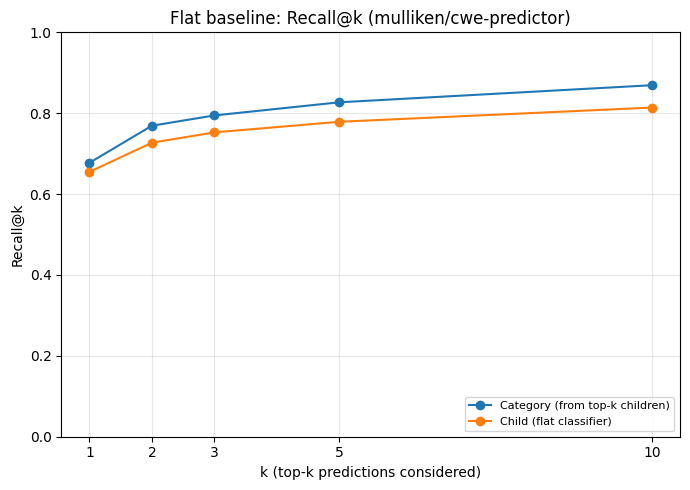

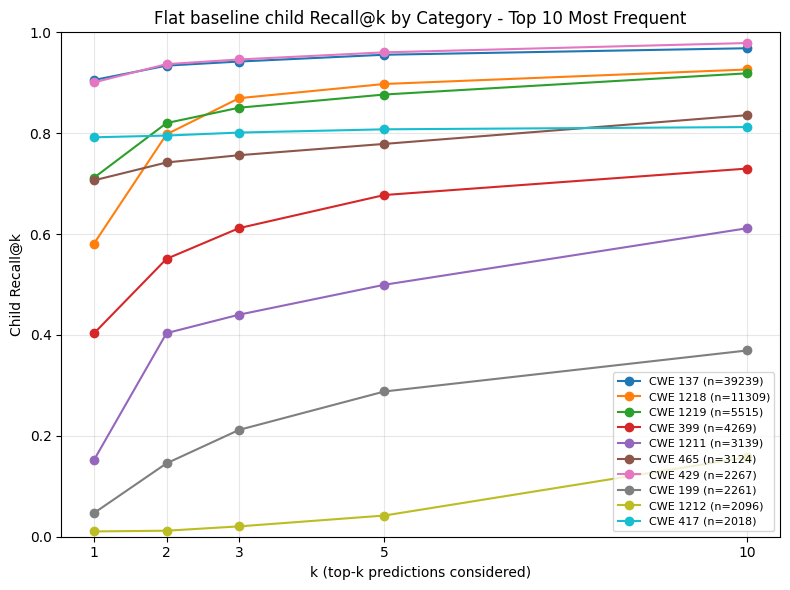

In [10]:

def recall_at_k(truths, predictions, k):
    """Hit if ANY true id is in the top-k predictions."""
    return np.mean([bool(set(t) & set(p[:k])) for t, p in zip(truths, predictions)])


ks = [1, 2, 3, 5, 10]

child_recall = [recall_at_k(CVE["true_children"], CVE["top_children_flat"], k) for k in ks]
# Category recall@k: is a true category among the categories of the top-k predicted children?
cat_recall = [
    recall_at_k(CVE["true_categories"], CVE["top_children_flat"].apply(
        lambda ch, k=k: categories_from_children(ch[:k])), len(CWE))
    for k in ks
]

print(f"{'k':>3} | {'child recall':>12} | {'category recall':>15}")
for k, c, a in zip(ks, child_recall, cat_recall):
    print(f"{k:>3} | {c:>12.3f} | {a:>15.3f}")

# %%
plt.figure(figsize=(7, 5))
plt.plot(ks, cat_recall, marker="o", label="Category (from top-k children)")
plt.plot(ks, child_recall, marker="o", label="Child (flat classifier)")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k predictions considered)")
plt.ylabel("Recall@k")
plt.title("Flat baseline: Recall@k (mulliken/cwe-predictor)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Per-category child recall@1 / @5 for the 10 most frequent categories
CVE["primary_category"] = CVE["true_categories"].str[0]
top_cats = CVE["primary_category"].value_counts().head(10).index.tolist()

plt.figure(figsize=(8, 6))
for cat in top_cats:
    s = CVE[CVE["primary_category"] == cat]
    plt.plot(ks, [recall_at_k(s["true_children"], s["top_children_flat"], k) for k in ks],
             marker="o", label=f"CWE {cat} (n={len(s)})")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k predictions considered)")
plt.ylabel("Child Recall@k")
plt.title("Flat baseline child Recall@k by Category - Top 10 Most Frequent")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()